In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, classification_report

In [19]:
# Load dataset
df = pd.read_csv(r"C:\Users\deeks\OneDrive\Desktop\yolo\archive (2)\data_banknote_authentication.csv")

# EDA
print("Shape:", df.shape)
print(df['Class'].value_counts())

Shape: (1373, 5)
Class
0.000000    762
1.000000    610
0.444606      1
Name: count, dtype: int64


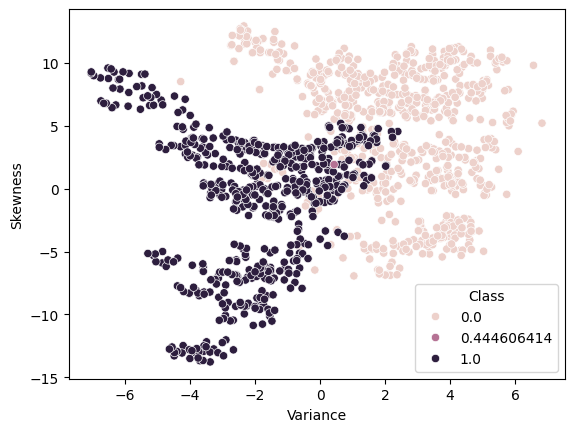

In [7]:
sns.scatterplot(x='Variance', y='Skewness', hue='Class', data=df)
plt.show()

In [8]:
# Split features and target
X = df.iloc[:, :-1]     # all columns except last
y = df.iloc[:, -1]      # last column only

In [9]:
# IMPORTANT: ensure integer labels
y = y.astype(int)

In [10]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

In [11]:
# scale only X
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [12]:
# elbow method
error_rate = []

for k in range(3,26):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    pred = knn.predict(X_test)

    error_rate.append(np.mean(pred != y_test))

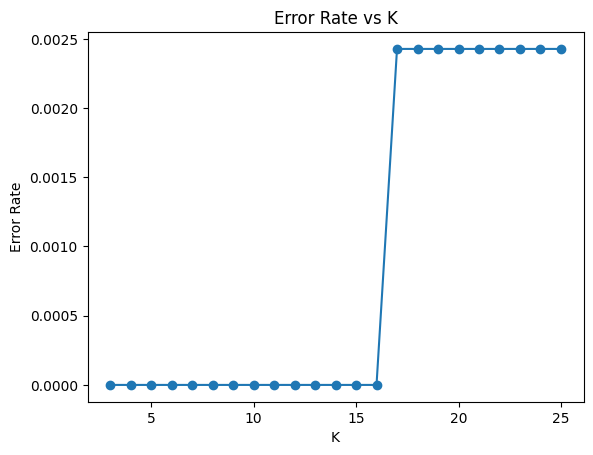

In [13]:
# plot
plt.plot(range(3,26), error_rate, marker='o')
plt.xlabel("K")
plt.ylabel("Error Rate")
plt.title("Error Rate vs K")
plt.show()


In [14]:
# best k
optimal_k = range(3,26)[np.argmin(error_rate)]
print("Best K:", optimal_k)

Best K: 3


In [15]:
# final model
knn = KNeighborsClassifier(n_neighbors=optimal_k)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

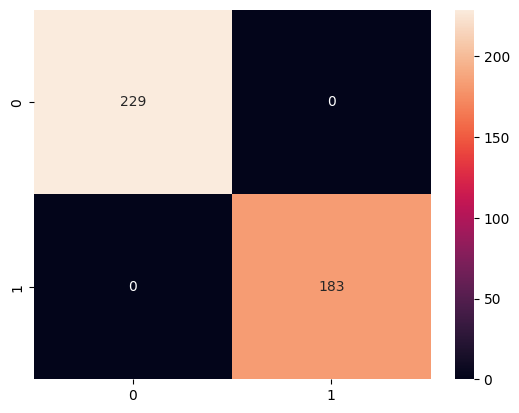

In [16]:
# confusion matrix
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.show()

In [17]:
# classification report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       229
           1       1.00      1.00      1.00       183

    accuracy                           1.00       412
   macro avg       1.00      1.00      1.00       412
weighted avg       1.00      1.00      1.00       412

